In [24]:
from pathlib import Path
from scipy.io import loadmat
import numpy as np
import pandas as pd

finger_path = Path("../dataset/fingerTappingData")

for folder in ["CTRL", "PD", "MSA", "PSP"]:
    files = list((finger_path / folder).glob("*.mat"))
    print(f"{folder}: {len(files)} files")

CTRL: 52 files
PD: 68 files
MSA: 72 files
PSP: 76 files


In [25]:
ctrl_file = list((finger_path / "CTRL").glob("*.mat"))[0]
pd_file = list((finger_path / "PD").glob("*.mat"))[0]

ctrl_data = loadmat(ctrl_file)
pd_data = loadmat(pd_file)

print("CTRL file:", ctrl_file.name)

print("\nCTRL variables:")
for key, value in ctrl_data.items():
    if not key.startswith("__"):
        print(
            f"{key:30s}",
            "shape =", np.shape(value),
            "type =", type(value)
        )

print("\n" + "=" * 60)

print("PD file:", pd_file.name)

print("\nPD variables:")
for key, value in pd_data.items():
    if not key.startswith("__"):
        print(
            f"{key:30s}",
            "shape =", np.shape(value),
            "type =", type(value)
        )

CTRL file: CTRLSR25_2.mat

CTRL variables:
diagnosis                      shape = (1,) type = <class 'numpy.ndarray'>
gyroThumbX                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroThumbY                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroThumbZ                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroIndexX                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroIndexY                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroIndexZ                     shape = (1, 3079) type = <class 'numpy.ndarray'>
fs                             shape = (1, 1) type = <class 'numpy.ndarray'>
person_id                      shape = (1,) type = <class 'numpy.ndarray'>
trial_id                       shape = (1,) type = <class 'numpy.ndarray'>

PD file: PDZD06_5.mat

PD variables:
diagnosis                      shape = (1,) type = <class 'numpy.ndarray'>
gyroThumbX                     shape = (1, 3554) type = <class

In [26]:
print("CTRL sampling frequency:", ctrl_data["fs"].flatten()[0])
print("PD sampling frequency:", pd_data["fs"].flatten()[0])

gyro_features = [
    "gyroThumbX",
    "gyroThumbY",
    "gyroThumbZ",
    "gyroIndexX",
    "gyroIndexY",
    "gyroIndexZ"
]

print("\nCTRL gyro shapes:")

for col in gyro_features:
    print(col, ctrl_data[col].shape)

print("\nFirst 10 Thumb Gyro X values:")
print(ctrl_data["gyroThumbX"].flatten()[:10])

CTRL sampling frequency: 200
PD sampling frequency: 200

CTRL gyro shapes:
gyroThumbX (1, 3079)
gyroThumbY (1, 3079)
gyroThumbZ (1, 3079)
gyroIndexX (1, 3079)
gyroIndexY (1, 3079)
gyroIndexZ (1, 3079)

First 10 Thumb Gyro X values:
[-0.65774812 -0.0854601  -0.04289322 -0.10437871  0.02805157  0.25034526
  0.25034526  0.35912728  0.45372035  0.57669132]


In [27]:
def create_gyro_windows(data, window_size=500, min_valid_ratio=0.90):

    n_samples = data[gyro_features[0]].size
    windows = []

    for start in range(
        0,
        n_samples - window_size + 1,
        window_size
    ):

        window = {}

        for feature in gyro_features:
            signal = data[feature].flatten()

            window[feature] = signal[
                start:start + window_size
            ]

        # Check validity
        valid = np.ones(
            window_size,
            dtype=bool
        )

        for feature in gyro_features:
            valid &= np.isfinite(window[feature])

        valid_ratio = valid.mean()

        if valid_ratio >= min_valid_ratio:
            windows.append(window)

    return windows

In [28]:
def extract_gyro_features(window):

    features = {}

    for col in gyro_features:

        signal = window[col]

        # Basic statistics
        features[f"{col}_mean"] = np.mean(signal)
        features[f"{col}_std"] = np.std(signal)
        features[f"{col}_min"] = np.min(signal)
        features[f"{col}_max"] = np.max(signal)

        # RMS
        features[f"{col}_rms"] = np.sqrt(
            np.mean(signal ** 2)
        )

        # Dynamic features
        diff = np.diff(signal)

        features[f"{col}_mean_abs_change"] = np.mean(
            np.abs(diff)
        )

        features[f"{col}_max_abs_change"] = np.max(
            np.abs(diff)
        )

        # Zero crossing rate
        centered = signal - np.mean(signal)

        zero_crossings = np.sum(
            centered[:-1] * centered[1:] < 0
        )

        features[f"{col}_zero_crossing_rate"] = (
            zero_crossings / (len(signal) - 1)
        )

    return features

In [29]:
ctrl_windows = create_gyro_windows(ctrl_data)
pd_windows = create_gyro_windows(pd_data)

print("CTRL windows:", len(ctrl_windows))
print("PD windows:", len(pd_windows))

ctrl_features = extract_gyro_features(
    ctrl_windows[0]
)

print("\nNumber of features:", len(ctrl_features))

print("\nSample features:")

for key, value in list(ctrl_features.items())[:10]:
    print(key, "=", value)

CTRL windows: 6
PD windows: 7

Number of features: 48

Sample features:
gyroThumbX_mean = 0.014553142381474914
gyroThumbX_std = 1.4941972430298889
gyroThumbX_min = -5.2171336410760905
gyroThumbX_max = 3.9252856710431727
gyroThumbX_rms = 1.4942681135028266
gyroThumbX_mean_abs_change = 0.44288129780314345
gyroThumbX_max_abs_change = 4.062771955049377
gyroThumbX_zero_crossing_rate = 0.10220440881763528
gyroThumbY_mean = 0.018325266352853916
gyroThumbY_std = 3.6222970494041764


In [30]:
all_features = []

# CTRL = 0
ctrl_files = list(
    (finger_path / "CTRL").glob("*.mat")
)

for file in ctrl_files:

    data = loadmat(file)

    windows = create_gyro_windows(data)

    for window_id, window in enumerate(windows):

        features = extract_gyro_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_features.append(features)


# PD = 1
pd_files = list(
    (finger_path / "PD").glob("*.mat")
)

for file in pd_files:

    data = loadmat(file)

    windows = create_gyro_windows(data)

    for window_id, window in enumerate(windows):

        features = extract_gyro_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_features.append(features)


finger_df = pd.DataFrame(all_features)

print("Shape:", finger_df.shape)
print("Recordings:", finger_df["recording_id"].nunique())
print("CTRL recordings:", len(ctrl_files))
print("PD recordings:", len(pd_files))

print("NaN:", finger_df.isna().sum().sum())

print(
    "Inf:",
    np.isinf(
        finger_df.select_dtypes(include=np.number)
    ).sum().sum()
)

Shape: (716, 51)
Recordings: 120
CTRL recordings: 52
PD recordings: 68
NaN: 0
Inf: 0


In [31]:
recording_info = []

for file in ctrl_files + pd_files:

    data = loadmat(file)

    person_id = str(
        data["person_id"].flatten()[0]
    )

    label = 0 if file.parent.name == "CTRL" else 1

    recording_info.append({
        "recording_id": file.name,
        "person_id": person_id,
        "label": label
    })

recording_info = pd.DataFrame(recording_info)

print("Total recordings:", len(recording_info))
print(
    "Unique persons:",
    recording_info["person_id"].nunique()
)

print("\nPersons by class:")
print(
    recording_info
    .drop_duplicates("person_id")
    ["label"]
    .value_counts()
)

Total recordings: 120
Unique persons: 25

Persons by class:
label
1    14
0    11
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

person_info = (
    recording_info[
        ["person_id", "label"]
    ]
    .drop_duplicates("person_id")
    .reset_index(drop=True)
)

train_persons, test_persons = train_test_split(
    person_info["person_id"].values,
    test_size=0.20,
    random_state=42,
    stratify=person_info["label"]
)

print("Train persons:", len(train_persons))
print("Test persons:", len(test_persons))

print(
    "Person overlap:",
    len(
        set(train_persons)
        & set(test_persons)
    )
)

Train persons: 20
Test persons: 5
Person overlap: 0


In [33]:
train_recordings = recording_info[
    recording_info["person_id"].isin(train_persons)
]["recording_id"].tolist()

test_recordings = recording_info[
    recording_info["person_id"].isin(test_persons)
]["recording_id"].tolist()

train_person_df = finger_df[
    finger_df["recording_id"].isin(train_recordings)
].copy()

test_person_df = finger_df[
    finger_df["recording_id"].isin(test_recordings)
].copy()

print("Train persons:", len(train_persons))
print("Test persons:", len(test_persons))

print("Train recordings:", len(train_recordings))
print("Test recordings:", len(test_recordings))

print("Train windows:", len(train_person_df))
print("Test windows:", len(test_person_df))

Train persons: 20
Test persons: 5
Train recordings: 98
Test recordings: 22
Train windows: 570
Test windows: 146


In [34]:
from sklearn.model_selection import train_test_split

person_info = (
    recording_info[
        ["person_id", "label"]
    ]
    .drop_duplicates("person_id")
    .reset_index(drop=True)
)

train_persons, test_persons = train_test_split(
    person_info["person_id"].values,
    test_size=0.20,
    random_state=42,
    stratify=person_info["label"]
)

print("Train persons:", len(train_persons))
print("Test persons:", len(test_persons))

print(
    "Person overlap:",
    len(
        set(train_persons)
        & set(test_persons)
    )
)

Train persons: 20
Test persons: 5
Person overlap: 0


In [35]:
train_recordings = recording_info[
    recording_info["person_id"].isin(train_persons)
]["recording_id"].tolist()

test_recordings = recording_info[
    recording_info["person_id"].isin(test_persons)
]["recording_id"].tolist()

train_person_df = finger_df[
    finger_df["recording_id"].isin(train_recordings)
].copy()

test_person_df = finger_df[
    finger_df["recording_id"].isin(test_recordings)
].copy()

print("Train persons:", len(train_persons))
print("Test persons:", len(test_persons))

print("Train recordings:", len(train_recordings))
print("Test recordings:", len(test_recordings))

print("Train windows:", len(train_person_df))
print("Test windows:", len(test_person_df))

Train persons: 20
Test persons: 5
Train recordings: 98
Test recordings: 22
Train windows: 570
Test windows: 146


In [36]:
recording_to_person = dict(
    zip(
        recording_info["recording_id"],
        recording_info["person_id"]
    )
)

train_person_df["person_id"] = (
    train_person_df["recording_id"]
    .map(recording_to_person)
)

test_person_df["person_id"] = (
    test_person_df["recording_id"]
    .map(recording_to_person)
)

print(
    "Train person IDs:",
    train_person_df["person_id"].nunique()
)

print(
    "Test person IDs:",
    test_person_df["person_id"].nunique()
)

print(
    "Overlap:",
    set(train_person_df["person_id"])
    & set(test_person_df["person_id"])
)

Train person IDs: 20
Test person IDs: 5
Overlap: set()


In [37]:
feature_cols = [
    col for col in finger_df.columns
    if col not in [
        "recording_id",
        "window_id",
        "label",
        "person_id"
    ]
]

print("Number of features:", len(feature_cols))

Number of features: 48


In [38]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_cv = train_person_df[feature_cols]
y_cv = train_person_df["label"]
groups_cv = train_person_df["person_id"]

cv_person = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

person_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv_person.split(
        X_cv,
        y_cv,
        groups=groups_cv
    ),
    start=1
):

    X_train_fold = X_cv.iloc[train_idx]
    y_train_fold = y_cv.iloc[train_idx]

    X_val_fold = X_cv.iloc[val_idx]

    val_df = train_person_df.iloc[val_idx].copy()

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    window_pred = model.predict(
        X_val_fold
    )

    val_df["prediction"] = window_pred

    # Window → recording
    recording_results = (
        val_df
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_results["pd_ratio"] = (
        recording_results["pd_windows"]
        / recording_results["total_windows"]
    )

    recording_results["final_prediction"] = (
        recording_results["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_results["actual_label"],
        recording_results["final_prediction"]
    )

    person_cv_scores.append(score)

    print(
        f"Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print(
    "\nCV Mean:",
    np.mean(person_cv_scores)
)

print(
    "CV Std:",
    np.std(person_cv_scores)
)

Fold 1: 1.0000 (100.00%)
Fold 2: 0.7391 (73.91%)
Fold 3: 1.0000 (100.00%)
Fold 4: 0.4348 (43.48%)
Fold 5: 0.7273 (72.73%)

CV Mean: 0.7802371541501977
CV Std: 0.20996440303005612


In [39]:
final_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    train_person_df[feature_cols],
    train_person_df["label"]
)

print("Final Random Forest trained.")

Final Random Forest trained.


In [40]:
test_window_pred = final_rf.predict(
    test_person_df[feature_cols]
)

test_results = test_person_df[
    ["recording_id", "person_id", "label"]
].copy()

test_results["prediction"] = test_window_pred

In [41]:
recording_test = (
    test_results
    .groupby("recording_id")
    .agg(
        person_id=("person_id", "first"),
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_test["pd_ratio"] = (
    recording_test["pd_windows"]
    / recording_test["total_windows"]
)

recording_test["final_prediction"] = (
    recording_test["pd_ratio"] >= 0.5
).astype(int)

print(recording_test)


      recording_id person_id  actual_label  pd_windows  total_windows  \
0   CTRLAM21_1.mat  CTRLAM21             0           5              5   
1   CTRLAM21_2.mat  CTRLAM21             0           5              5   
2   CTRLAM21_3.mat  CTRLAM21             0           5              5   
3   CTRLAM21_4.mat  CTRLAM21             0           6              6   
4   CTRLAM21_5.mat  CTRLAM21             0           5              6   
5   CTRLZI04_1.mat  CTRLZI04             0           5              9   
6   CTRLZI04_2.mat  CTRLZI04             0           0              7   
7   CTRLZI04_3.mat  CTRLZI04             0           0              8   
8   CTRLZI04_4.mat  CTRLZI04             0           0              7   
9     PDBS13_1.mat    PDBS13             1           8              8   
10    PDBS13_2.mat    PDBS13             1           7              7   
11    PDBS13_3.mat    PDBS13             1           7              7   
12    PDBS13_4.mat    PDBS13             1         

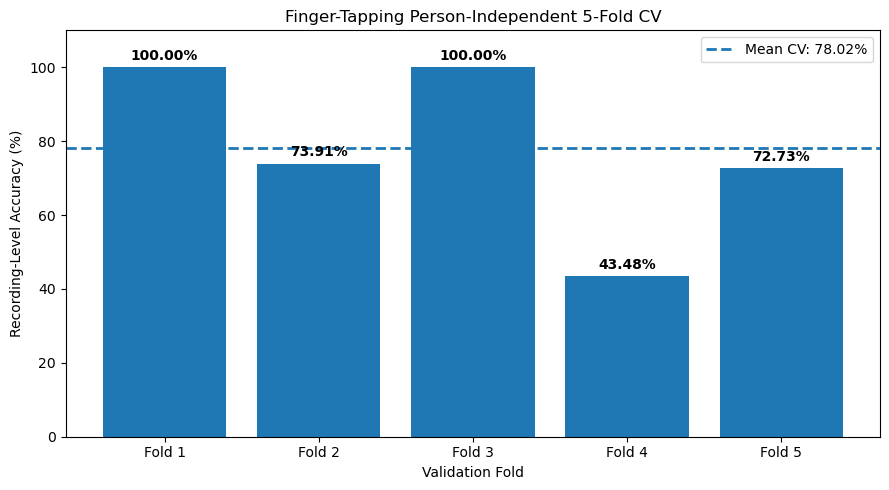

In [42]:
import matplotlib.pyplot as plt

cv_scores = np.array(person_cv_scores) * 100

mean_cv = cv_scores.mean()

fold_labels = [
    f"Fold {i}"
    for i in range(1, len(cv_scores) + 1)
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    fold_labels,
    cv_scores
)

plt.axhline(
    mean_cv,
    linestyle="--",
    linewidth=2,
    label=f"Mean CV: {mean_cv:.2f}%"
)

for bar, score in zip(bars, cv_scores):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 2,
        f"{score:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.xlabel("Validation Fold")
plt.ylabel("Recording-Level Accuracy (%)")

plt.title(
    "Finger-Tapping Person-Independent 5-Fold CV"
)

plt.ylim(0, 110)
plt.legend()

plt.tight_layout()

plt.savefig(
    "Finger_Tapping_CV_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

y_true = recording_test["actual_label"]
y_pred = recording_test["final_prediction"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Finger Tapping Person-Independent "
    f"Recording Accuracy: "
    f"{accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["CTRL", "PD"]
    )
)

Finger Tapping Person-Independent Recording Accuracy: 0.7273 (72.73%)

Confusion Matrix:
[[ 3  6]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

        CTRL       1.00      0.33      0.50         9
          PD       0.68      1.00      0.81        13

    accuracy                           0.73        22
   macro avg       0.84      0.67      0.66        22
weighted avg       0.81      0.73      0.68        22



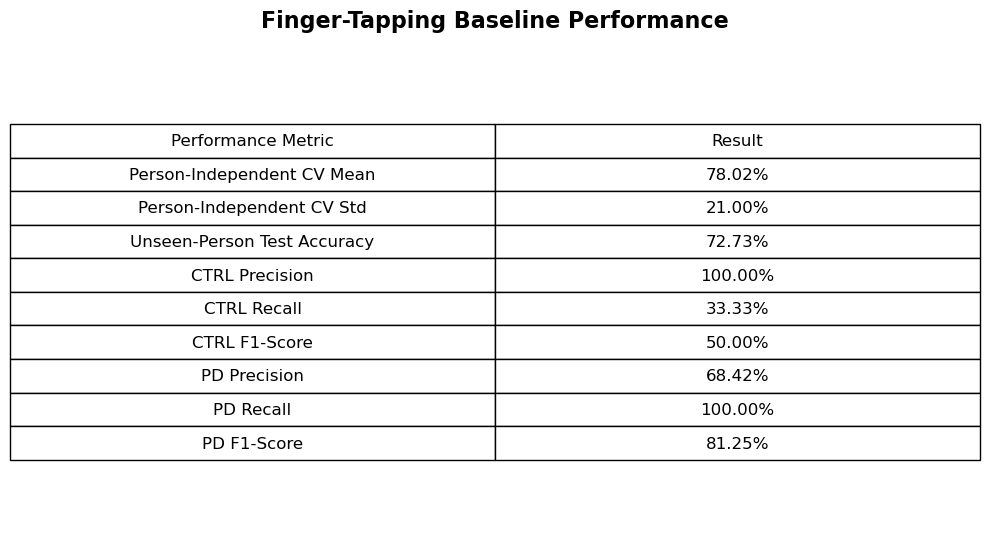

In [44]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

cv_mean = np.mean(person_cv_scores)
cv_std = np.std(person_cv_scores)

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

ctrl_precision = precision_score(
    y_true,
    y_pred,
    pos_label=0
)

ctrl_recall = recall_score(
    y_true,
    y_pred,
    pos_label=0
)

ctrl_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=0
)

pd_precision = precision_score(
    y_true,
    y_pred,
    pos_label=1
)

pd_recall = recall_score(
    y_true,
    y_pred,
    pos_label=1
)

pd_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1
)

table_data = [
    ["Person-Independent CV Mean", f"{cv_mean * 100:.2f}%"],
    ["Person-Independent CV Std", f"{cv_std * 100:.2f}%"],
    ["Unseen-Person Test Accuracy", f"{test_accuracy * 100:.2f}%"],
    ["CTRL Precision", f"{ctrl_precision * 100:.2f}%"],
    ["CTRL Recall", f"{ctrl_recall * 100:.2f}%"],
    ["CTRL F1-Score", f"{ctrl_f1 * 100:.2f}%"],
    ["PD Precision", f"{pd_precision * 100:.2f}%"],
    ["PD Recall", f"{pd_recall * 100:.2f}%"],
    ["PD F1-Score", f"{pd_f1 * 100:.2f}%"]
]

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=[
        "Performance Metric",
        "Result"
    ],
    loc="center",
    cellLoc="center",
    colLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

plt.title(
    "Finger-Tapping Baseline Performance",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "Finger_Tapping_Performance_Table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()